<a href="https://colab.research.google.com/github/Goal48/kaggle-s6e4-irrigation/blob/main/kaggle_s6e4_irrigation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
## Load Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import balanced_accuracy_score
from xgboost import XGBClassifier
#from catboost import CatBoostClassifier
import lightgbm as lgb
import pickle
print("Loaded the libraries")

Loaded the libraries


In [13]:
## load the dataset
df = pd.read_csv("/content/train.csv")
df.head()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


Data transformation

1.   Data info
2.   Missing values




In [14]:
df.shape

(630000, 21)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Soil_Type                630000 non-null  object 
 2   Soil_pH                  630000 non-null  float64
 3   Soil_Moisture            630000 non-null  float64
 4   Organic_Carbon           630000 non-null  float64
 5   Electrical_Conductivity  630000 non-null  float64
 6   Temperature_C            630000 non-null  float64
 7   Humidity                 630000 non-null  float64
 8   Rainfall_mm              630000 non-null  float64
 9   Sunlight_Hours           630000 non-null  float64
 10  Wind_Speed_kmh           630000 non-null  float64
 11  Crop_Type                630000 non-null  object 
 12  Crop_Growth_Stage        630000 non-null  object 
 13  Season                   630000 non-null  object 
 14  Irri

In [16]:
df.isnull().sum()

,0
id,0
Soil_Type,0
Soil_pH,0
Soil_Moisture,0
Organic_Carbon,0
Electrical_Conductivity,0
Temperature_C,0
Humidity,0
Rainfall_mm,0
Sunlight_Hours,0


That means the dataset have no missing values

In [17]:
df.isna().sum()

,0
id,0
Soil_Type,0
Soil_pH,0
Soil_Moisture,0
Organic_Carbon,0
Electrical_Conductivity,0
Temperature_C,0
Humidity,0
Rainfall_mm,0
Sunlight_Hours,0


In [18]:
## Categorical Columns
cat_cols = df.select_dtypes(include='object').columns

print(cat_cols)


Index(['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season',
       'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region',
       'Irrigation_Need'],
      dtype='object')


In [19]:
## Nuerical Columns
num_cols = df.select_dtypes(exclude='object').columns

print(num_cols)

Index(['id', 'Soil_pH', 'Soil_Moisture', 'Organic_Carbon',
       'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm',
       'Sunlight_Hours', 'Wind_Speed_kmh', 'Field_Area_hectare',
       'Previous_Irrigation_mm'],
      dtype='object')



Value Counts for Soil_Type:
Soil_Type
Sandy    166509
Clay     158470
Loamy    156455
Silt     148566
Name: count, dtype: int64

Bar plot of each value count for Soil_Type


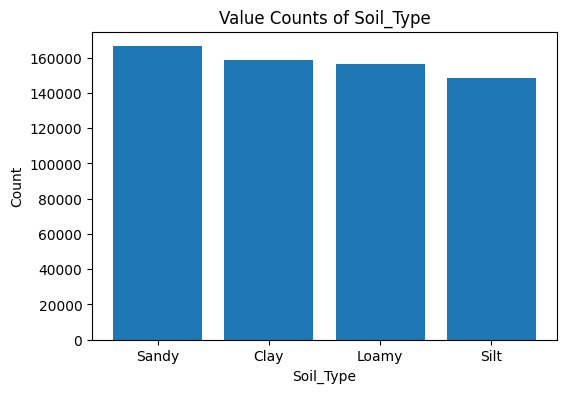


Value Counts for Crop_Type:
Crop_Type
Sugarcane    108910
Rice         106697
Cotton       104645
Maize        104274
Wheat        103005
Potato       102469
Name: count, dtype: int64

Bar plot of each value count for Crop_Type


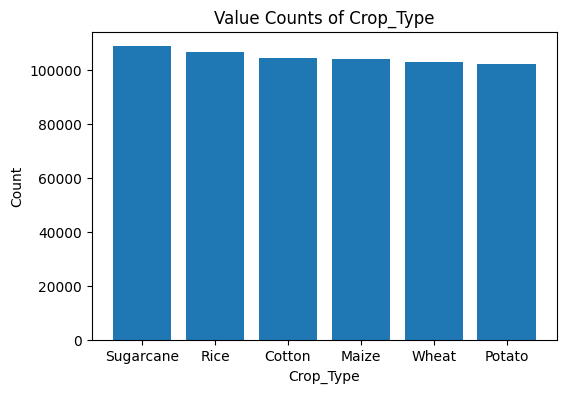


Value Counts for Crop_Growth_Stage:
Crop_Growth_Stage
Harvest       167689
Flowering     157563
Vegetative    157246
Sowing        147502
Name: count, dtype: int64

Bar plot of each value count for Crop_Growth_Stage


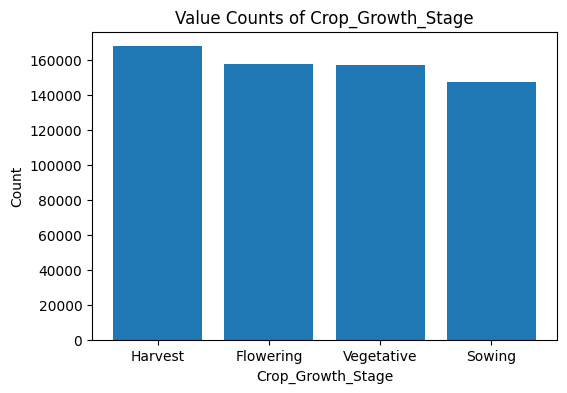


Value Counts for Season:
Season
Kharif    216561
Rabi      208033
Zaid      205406
Name: count, dtype: int64

Bar plot of each value count for Season


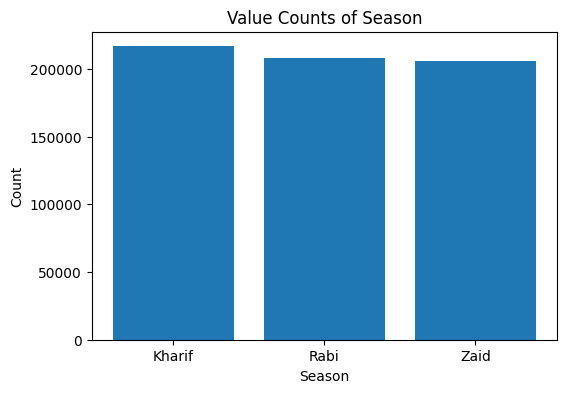


Value Counts for Irrigation_Type:
Irrigation_Type
Canal        161901
Sprinkler    161400
Rainfed      155607
Drip         151092
Name: count, dtype: int64

Bar plot of each value count for Irrigation_Type


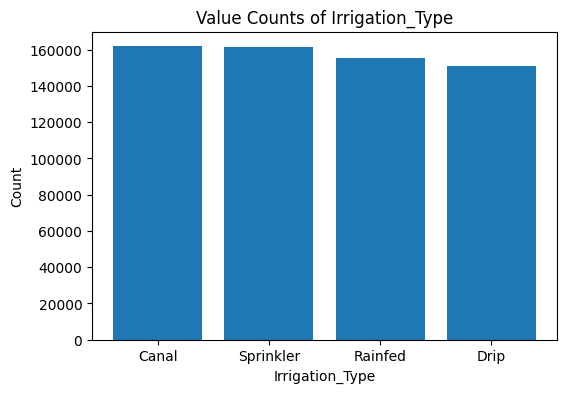


Value Counts for Water_Source:
Water_Source
Reservoir      162994
River          159819
Groundwater    154155
Rainwater      153032
Name: count, dtype: int64

Bar plot of each value count for Water_Source


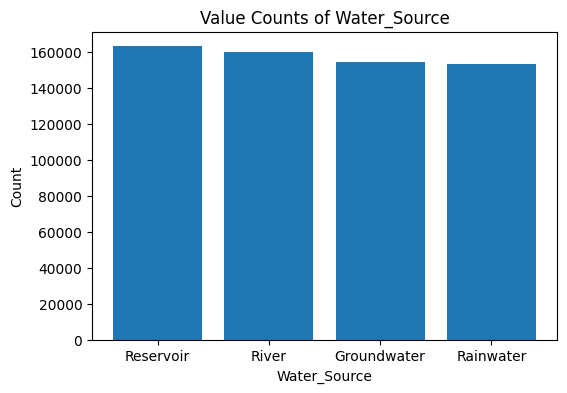


Value Counts for Mulching_Used:
Mulching_Used
No     316453
Yes    313547
Name: count, dtype: int64

Bar plot of each value count for Mulching_Used


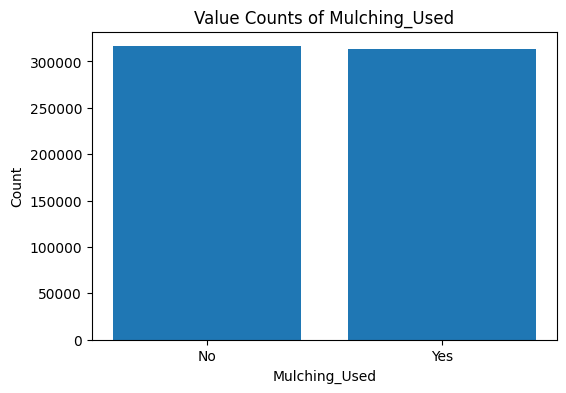


Value Counts for Region:
Region
South      134809
West       131189
East       126163
Central    123712
North      114127
Name: count, dtype: int64

Bar plot of each value count for Region


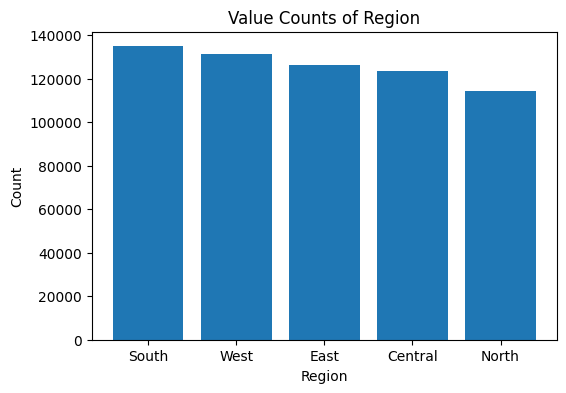


Value Counts for Irrigation_Need:
Irrigation_Need
Low       369917
Medium    239074
High       21009
Name: count, dtype: int64

Bar plot of each value count for Irrigation_Need


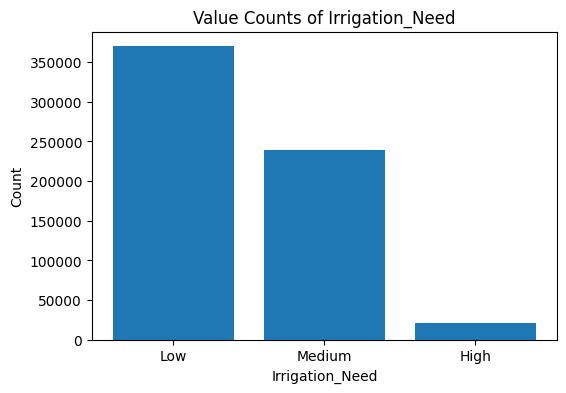

In [20]:
## Value Counts of the Categorical columns
def value_counts_cat(df,columns):
  for col in columns :
      print(f"\nValue Counts for {col}:")
      print(df[col].value_counts())

      print(f"\nBar plot of each value count for {col}")

      counts = df[col].value_counts()

      plt.figure(figsize=(6,4))
      plt.bar(counts.index, counts.values)
      plt.xlabel(col)
      plt.ylabel("Count")
      plt.title(f"Value Counts of {col}")
      plt.show()

value_counts_cat(df,cat_cols)

In the Categorical columns value counts shows that the "Irrigation_Need" columns is imbalanced

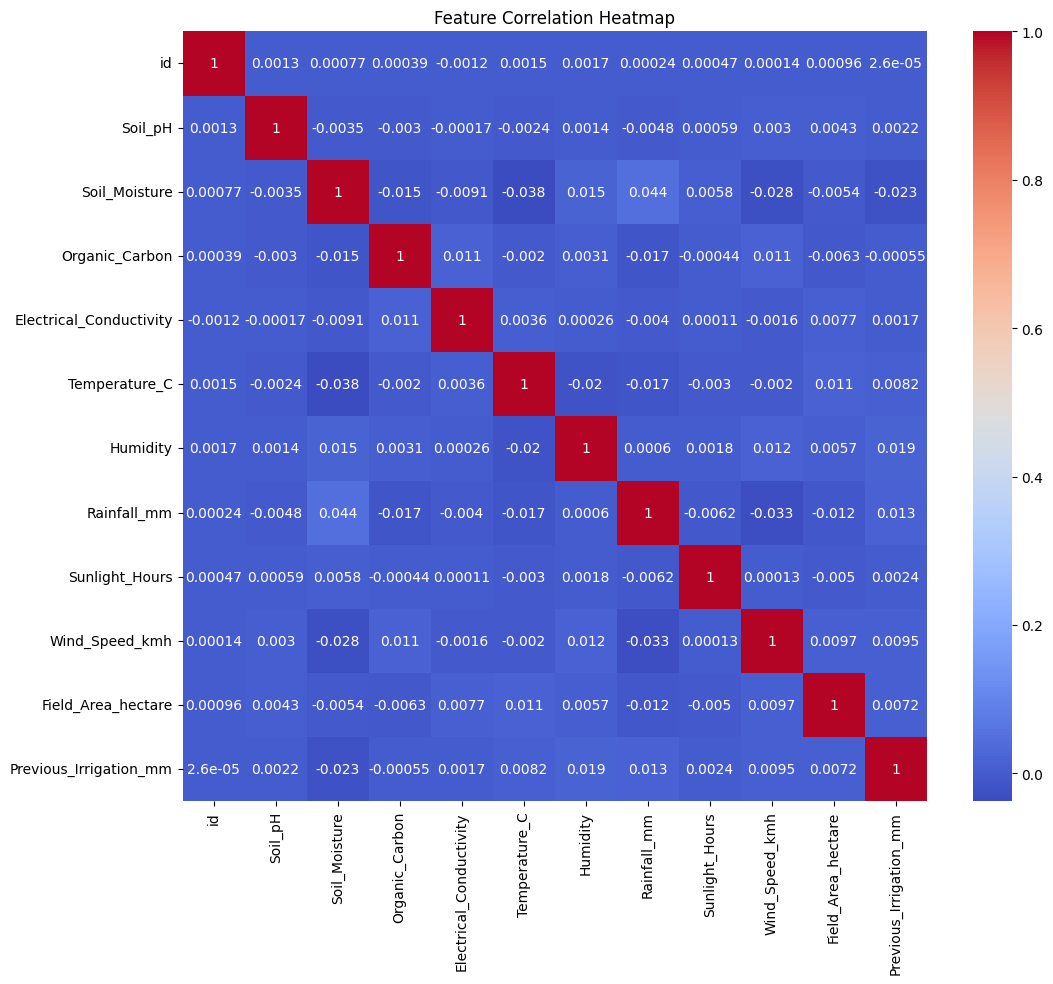

In [21]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Feature Correlation Heatmap")
plt.show()

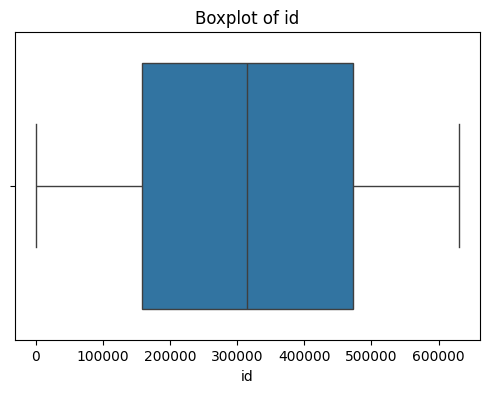

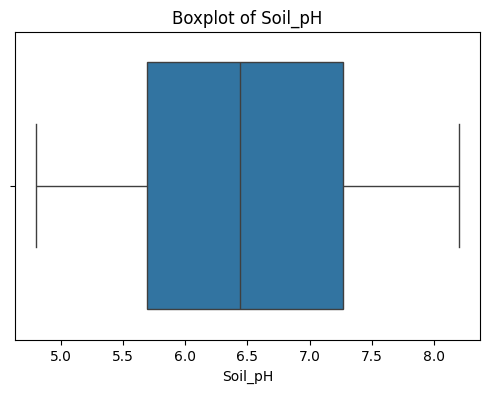

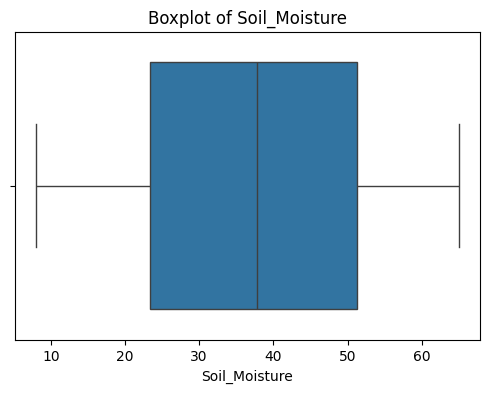

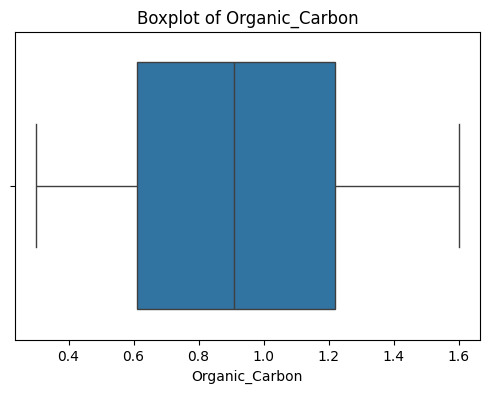

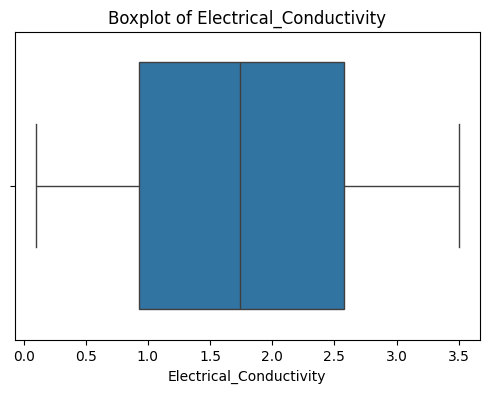

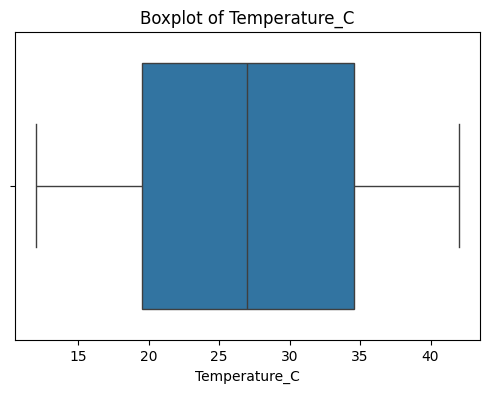

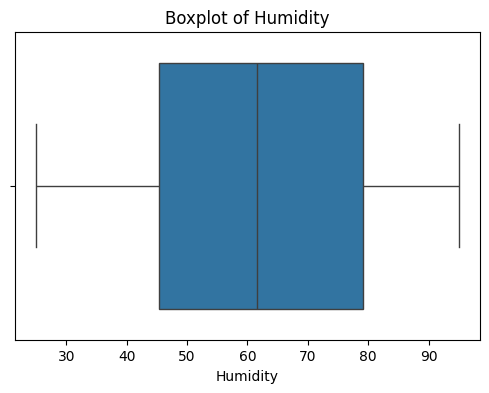

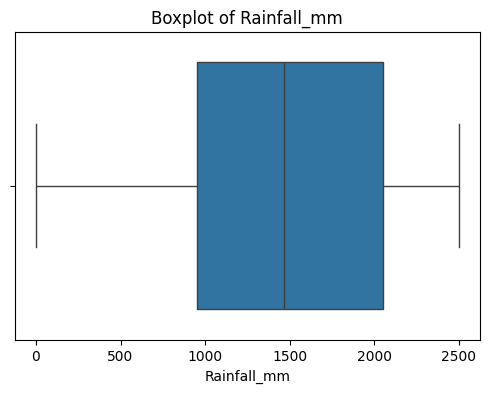

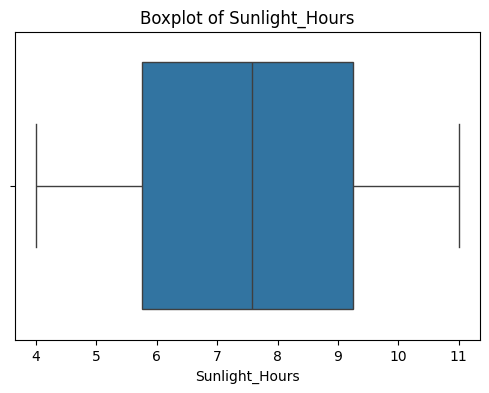

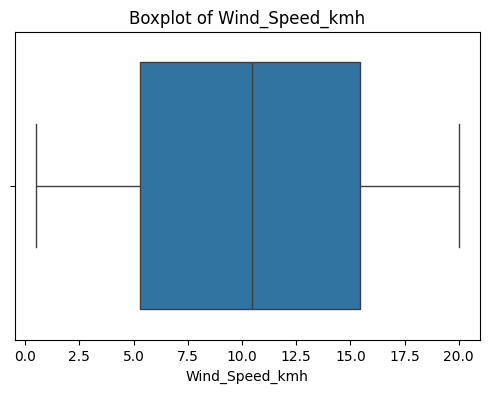

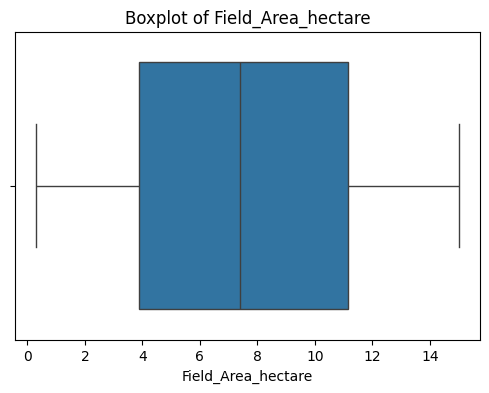

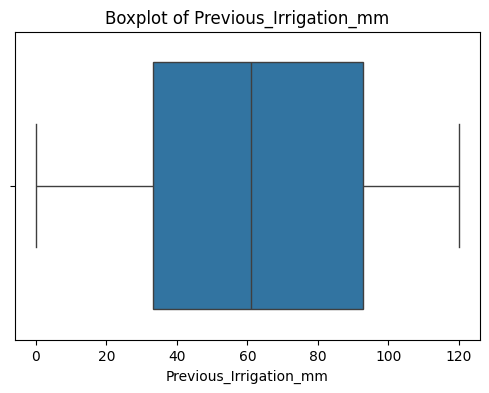

In [22]:
def boxplot_num(df, columns):

    for col in columns:

        plt.figure(figsize=(6,4))

        sns.boxplot(x=df[col])

        plt.title(f"Boxplot of {col}")

        plt.show()

boxplot_num(df, num_cols)

It is said that No outleir present in the dataset

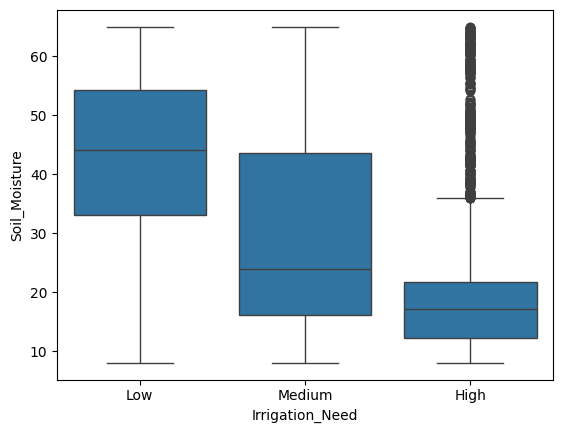

In [23]:
sns.boxplot(
    x='Irrigation_Need',
    y='Soil_Moisture',
    data=df
)

plt.show()

Features Engineering
1.  Moisture_Deficit
2.  Evaporation_Risk
3.  Climate_Stress
4.  Soil_Crop
5.  Season_Stage
6.  Crop_Water_Stress

In [24]:
df.shape

(630000, 21)

In [25]:
cat_cols

Index(['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season',
       'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region',
       'Irrigation_Need'],
      dtype='object')

In [26]:


def one_hot_encoding(df, target_col=None, drop_first=True):

    # Separate target column
    if target_col:
        y = df[target_col]
        X = df.drop(columns=[target_col])
    else:
        X = df.copy()

    # Select categorical columns
    cat_cols = X.select_dtypes(include='object').columns

    # Apply One Hot Encoding
    X_encoded = pd.get_dummies(
        X,
        columns=cat_cols,
        drop_first=drop_first
    )

    # Add target back
    if target_col:
        X_encoded[target_col] = y.values

    return X_encoded

In [27]:
df_encoded = one_hot_encoding(
    df,
    target_col='Irrigation_Need'
)

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Soil_Type                630000 non-null  object 
 2   Soil_pH                  630000 non-null  float64
 3   Soil_Moisture            630000 non-null  float64
 4   Organic_Carbon           630000 non-null  float64
 5   Electrical_Conductivity  630000 non-null  float64
 6   Temperature_C            630000 non-null  float64
 7   Humidity                 630000 non-null  float64
 8   Rainfall_mm              630000 non-null  float64
 9   Sunlight_Hours           630000 non-null  float64
 10  Wind_Speed_kmh           630000 non-null  float64
 11  Crop_Type                630000 non-null  object 
 12  Crop_Growth_Stage        630000 non-null  object 
 13  Season                   630000 non-null  object 
 14  Irri

In [29]:
X = df.drop(['id', 'Irrigation_Need'], axis=1)
y = df['Irrigation_Need']

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [31]:
cat_cols = X_train.select_dtypes(include='object').columns

cat_cols

Index(['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season',
       'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region'],
      dtype='object')

In [33]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.0 MB/s eta 0:00:00


In [34]:
from catboost import CatBoostClassifier

model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=8,
    loss_function='MultiClass',
    eval_metric='BalancedAccuracy',
    verbose=100
)

In [35]:
cat_cols = X_train.select_dtypes(
    include='object'
).columns.tolist()

In [40]:
from catboost import CatBoostClassifier

model = CatBoostClassifier(
    loss_function='MultiClass',
    eval_metric='MultiClass',
    iterations=500,
    learning_rate=0.05,
    depth=6
)

model.fit(
    X_train,
    y_train,
    cat_features=cat_cols,
    eval_set=(X_valid, y_valid),
    verbose=100
)

0:	learn: 1.0064261	test: 1.0063512	best: 1.0063512 (0)	total: 3.36s	remaining: 27m 58s
100:	learn: 0.0685125	test: 0.0665543	best: 0.0665543 (100)	total: 5m 36s	remaining: 22m 11s
200:	learn: 0.0633805	test: 0.0618039	best: 0.0618039 (200)	total: 10m 53s	remaining: 16m 11s
300:	learn: 0.0621125	test: 0.0608663	best: 0.0608663 (300)	total: 16m	remaining: 10m 35s
400:	learn: 0.0611213	test: 0.0602415	best: 0.0602415 (400)	total: 21m 17s	remaining: 5m 15s
499:	learn: 0.0603120	test: 0.0597785	best: 0.0597785 (499)	total: 26m 29s	remaining: 0us

bestTest = 0.05977846266
bestIteration = 499



CatBoostClassifier(depth=6, eval_metric='MultiClass', iterations=500, learning_rate=0.05, loss_function='MultiClass')

In [41]:
preds = model.predict(X_valid)

In [42]:
score = balanced_accuracy_score(
    y_valid,
    preds
)

print(score)

0.9635886212984617


In [43]:
test_df = pd.read_csv("/content/test.csv")

In [45]:
def one_hot_encoding(test_df, target_col=None, drop_first=True):

    # Separate target column
    if target_col:
        y = df[target_col]
        X = df.drop(columns=[target_col])
    else:
        X = df.copy()

    # Select categorical columns
    cat_cols = X.select_dtypes(include='object').columns

    # Apply One Hot Encoding
    X_encoded = pd.get_dummies(
        X,
        columns=cat_cols,
        drop_first=drop_first
    )

    # Add target back
    if target_col:
        X_encoded[target_col] = y.values

    return X_encoded

In [46]:
one_hot_encoding(test_df)

,id,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,...,Water_Source_Rainwater,Water_Source_Reservoir,Water_Source_River,Mulching_Used_Yes,Region_East,Region_North,Region_South,Region_West,Irrigation_Need_Low,Irrigation_Need_Medium
0,0,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,16.79,...,True,False,False,False,True,False,False,False,True,False
1,1,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,3.39,...,False,False,True,True,False,False,True,False,True,False
2,2,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,3.85,...,False,True,False,True,False,True,False,False,True,False
3,3,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,2.31,...,False,False,True,True,False,False,True,False,False,True
4,4,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,13.94,...,False,False,True,False,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
629995,629995,6.54,13.45,1.15,1.86,26.65,26.86,1041.33,10.62,18.85,...,False,False,True,False,False,False,True,False,False,True
629996,629996,7.03,54.49,0.96,2.35,36.99,88.00,1419.57,9.93,17.99,...,False,False,False,True,False,False,False,False,False,True
629997,629997,6.52,11.98,0.93,0.38,37.82,70.98,88.45,8.19,17.25,...,False,True,False,True,False,False,True,False,False,False
629998,629998,5.93,42.86,0.33,3.39,34.99,94.58,2433.92,9.88,5.00,...,False,False,False,True,True,False,False,False,True,False


In [48]:
test_X = test_df.drop('id', axis=1)

In [50]:
set(X_train.columns) - set(test_X.columns)

set()

In [52]:
test_df.info(

)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270000 entries, 0 to 269999
Data columns (total 20 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       270000 non-null  int64  
 1   Soil_Type                270000 non-null  object 
 2   Soil_pH                  270000 non-null  float64
 3   Soil_Moisture            270000 non-null  float64
 4   Organic_Carbon           270000 non-null  float64
 5   Electrical_Conductivity  270000 non-null  float64
 6   Temperature_C            270000 non-null  float64
 7   Humidity                 270000 non-null  float64
 8   Rainfall_mm              270000 non-null  float64
 9   Sunlight_Hours           270000 non-null  float64
 10  Wind_Speed_kmh           270000 non-null  float64
 11  Crop_Type                270000 non-null  object 
 12  Crop_Growth_Stage        270000 non-null  object 
 13  Season                   270000 non-null  object 
 14  Irri

In [51]:
test_preds = model.predict(test_df)

CatBoostError: Bad value for num_feature[non_default_doc_idx=0,feature_idx=1]="Silt": Cannot convert 'Silt' to float

In [ ]:
submission = pd.DataFrame({
    'id': test_df['id'],
    'Irrigation_Need': test_preds.flatten()
})

submission.to_csv(
    'submission.csv',
    index=False
)